In [243]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [244]:
## load ROI intensity for Fucci ROI data after filtering with codex settings
csv_path = r"D:\_data\_newAAV_2026\Fucci-Tri_avg_images\1050_data\analysis\roi_log_ratio_outputs_dark_median_corrected_meanMergeCPSAM_ROIs\roi_intensity_results_dark_median_corrected_meanMergeCPSAM_ROIs_long.csv"
df_roi = pd.read_csv(csv_path)
df_roi.head()

## ROI QC csv file
df_roi_qc_path = r"D:\_data\_newAAV_2026\Fucci-Tri_avg_images\1050_data\analysis\roi_log_ratio_outputs_dark_median_corrected_meanMergeCPSAM_ROIs\shape_qc_filter\roi_size_table_with_shape_qc.csv"
df_roi_qc = pd.read_csv(df_roi_qc_path)
df_roi_qc.head()
passed_qc_roi_ids = df_roi_qc[df_roi_qc['shape_qc_pass']==True]['roi_id'].values
passed_qc_roi_ids

## drop ROIs that has NaN values in mean_intensity_corrected in any day/channel, as those are likely ROIs that were filtered out by codex settings and have no valid intensity values
# df_roi = df_roi.dropna(subset=['mean_intensity_corrected'])

df_roi = df_roi[df_roi['roi_id'].isin(passed_qc_roi_ids)]
print(f"Number of ROIs that passed QC: {len(df_roi['roi_id'].unique())}")
df_roi.head()

Number of ROIs that passed QC: 5255


,roi_id,image,channel,mean_intensity,day,dark_value,mean_intensity_corrected
0,1,20260511_G.tif,green,426.379836,0,319.0,107.379836
1,1,20260511_R.tif,red,1598.295428,0,534.0,1064.295428
2,1,20260512_G_SyN.tif,green,414.949590,1,319.0,95.949590
3,1,20260512_R_SyN.tif,red,1507.411489,1,534.0,973.411489
4,1,20260513_G_SyN.tif,green,419.518171,2,319.0,100.518171


In [245]:
filtered_roi_path = r"D:\_data\_newAAV_2026\Fucci-Tri_avg_images\1050_data\analysis\roi_log_ratio_outputs_dark_median_corrected_meanMergeCPSAM_ROIs\shape_qc_filter\roi_log_ratio_metrics_size_and_shape_filtered.csv"
roi_df = pd.read_csv(filtered_roi_path)
roi_df.head()

,roi_id,day,green,red,brightness,green_fraction,log2_green_over_red,day0_log2_green_over_red,delta_log2_green_over_red,green_day0,green_day0_normalized,proj_perimeter_px,circularity,solidity,eccentricity,axis_ratio,shape_qc_pass,shape_qc_min_circularity,shape_qc_min_solidity,shape_qc_max_axis_ratio
0,1,0,107.379836,1064.295428,1171.675264,0.091646,-3.297085,-3.297085,0.000000,107.379836,1.000000,49.108522,0.922294,0.936508,0.583614,1.23148,True,0.65,0.8,2.0
1,1,1,95.949590,973.411489,1069.361079,0.089726,-3.329224,-3.297085,-0.032139,107.379836,0.893553,49.108522,0.922294,0.936508,0.583614,1.23148,True,0.65,0.8,2.0
2,1,2,100.518171,979.194607,1079.712778,0.093097,-3.271330,-3.297085,0.025755,107.379836,0.936099,49.108522,0.922294,0.936508,0.583614,1.23148,True,0.65,0.8,2.0
3,1,3,91.513482,840.206331,931.719812,0.098220,-3.184724,-3.297085,0.112361,107.379836,0.852241,49.108522,0.922294,0.936508,0.583614,1.23148,True,0.65,0.8,2.0
4,1,4,101.083236,916.048066,1017.131301,0.099381,-3.167251,-3.297085,0.129834,107.379836,0.941361,49.108522,0.922294,0.936508,0.583614,1.23148,True,0.65,0.8,2.0


In [246]:
df_roi_melted = df_roi.melt(id_vars=['day', 'channel','roi_id'], value_vars=['mean_intensity_corrected'], var_name='metric', value_name='value')
df_roi_melted.head()
# sns.pointplot(data=df_roi_melted, x='day', y='value', hue='channel')

## warp matrix 

,day,channel,roi_id,metric,value
0,0,green,1,mean_intensity_corrected,107.379836
1,0,red,1,mean_intensity_corrected,1064.295428
2,1,green,1,mean_intensity_corrected,95.949590
3,1,red,1,mean_intensity_corrected,973.411489
4,2,green,1,mean_intensity_corrected,100.518171


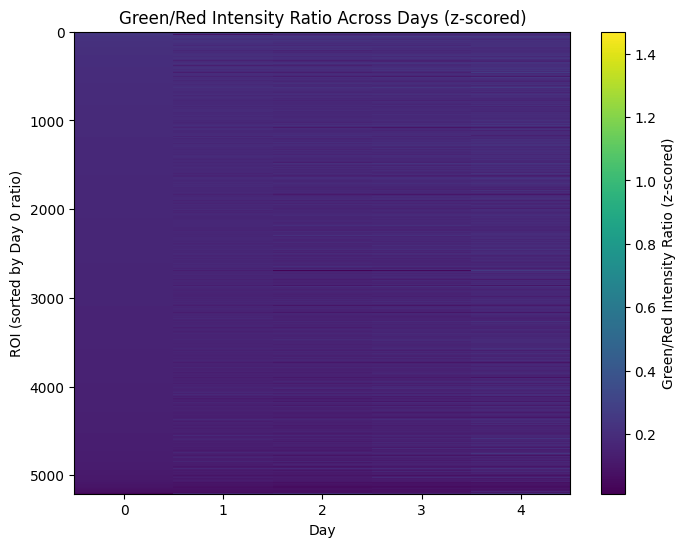

In [247]:
## convert df to 2D matrix with only green or only red values for each day, then plot as heatmap    
## each ROI is a row, each day is a column, and the value is the mean intensity for that ROI on that day. Do this separately for green and red channels.
df_green = df_roi[df_roi['channel'] == 'green']
df_red = df_roi[df_roi['channel'] == 'red']
green_matrix = df_green.pivot(index='roi_id', columns='day', values='mean_intensity_corrected')
red_matrix = df_red.pivot(index='roi_id', columns='day', values='mean_intensity_corrected')
green_red_ratio_matrix = green_matrix / red_matrix
green_red_ratio_matrix.dropna(inplace=True)

# green_red_ratio_matrix = np.log2(green_red_ratio_matrix)

## do zscore normalization across days for each ROI separately for green red ratio
# means = green_red_ratio_matrix.mean(axis=1)
# stds = green_red_ratio_matrix.std(axis=1)
# green_red_ratio_matrix = green_red_ratio_matrix.sub(means, axis=0).div(stds, axis=0)


# for i in range(green_red_ratio_matrix.shape[1]):
# isort = np.argsort(green_red_ratio_matrix[4] - green_red_ratio_matrix[0])
isort = np.argsort(-green_red_ratio_matrix[0])
green_red_ratio_matrix = green_red_ratio_matrix.iloc[isort, :]

plt.figure(figsize=(8, 6))
plt.imshow(green_red_ratio_matrix, aspect='auto', cmap='viridis',interpolation='none')#,vmin=-3.5, vmax=-1.5)
plt.colorbar(label='Green/Red Intensity Ratio (z-scored)')
plt.xlabel('Day')
plt.ylabel('ROI (sorted by Day 0 ratio)')
plt.title('Green/Red Intensity Ratio Across Days (z-scored)')
plt.show()
# sns.heatmap(green_matrix, cmap='Greens', cbar_kws={'label': 'Mean Intensity (Green)'})
# plt.title('Green Channel ROI Intensity Across Days')

Text(0.5, 1.0, 'Green/Red Intensity Ratio Across Days (z-scored)')

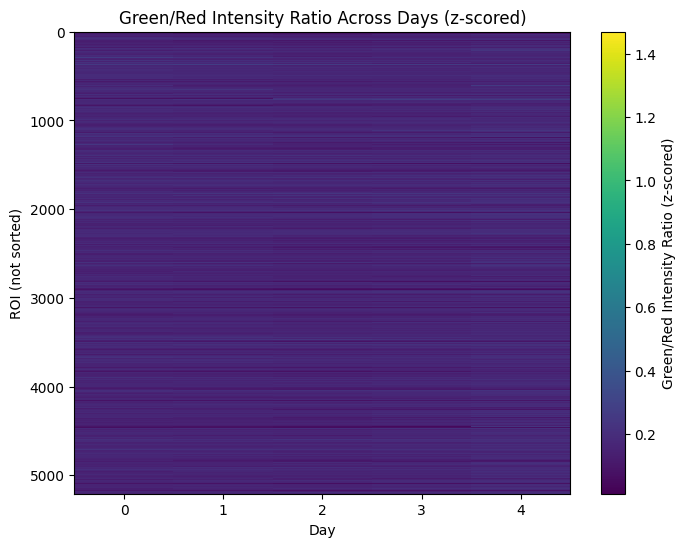

In [248]:
## convert df to 2D matrix with only green or only red values for each day, then plot as heatmap    
## each ROI is a row, each day is a column, and the value is the mean intensity for that ROI on that day. Do this separately for green and red channels.
df_green = df_roi[df_roi['channel'] == 'green']
df_red = df_roi[df_roi['channel'] == 'red']
green_matrix = df_green.pivot(index='roi_id', columns='day', values='mean_intensity_corrected')
red_matrix = df_red.pivot(index='roi_id', columns='day', values='mean_intensity_corrected')
green_red_ratio_matrix = green_matrix / red_matrix
green_red_ratio_matrix.dropna(inplace=True)
## do zscore normalization across days for each ROI separately for green red ratio
# means = green_red_ratio_matrix.mean(axis=1)
# stds = green_red_ratio_matrix.std(axis=1)
# green_red_ratio_matrix = green_red_ratio_matrix.sub(means, axis=0).div(stds, axis=0)

# isort = np.argsort(green_red_ratio_matrix[4] - green_red_ratio_matrix[0])
# isort = np.argsort(-green_red_ratio_matrix[0])
# green_red_ratio_matrix = green_red_ratio_matrix.iloc[isort, :]

plt.figure(figsize=(8, 6))
plt.imshow(green_red_ratio_matrix, aspect='auto', cmap='viridis',interpolation='none')
plt.colorbar(label='Green/Red Intensity Ratio (z-scored)')
plt.xlabel('Day')
plt.ylabel('ROI (not sorted)')
plt.title('Green/Red Intensity Ratio Across Days (z-scored)')
# sns.heatmap(green_matrix, cmap='Greens', cbar_kws={'label': 'Mean Intensity (Green)'})
# plt.title('Green Channel ROI Intensity Across Days')

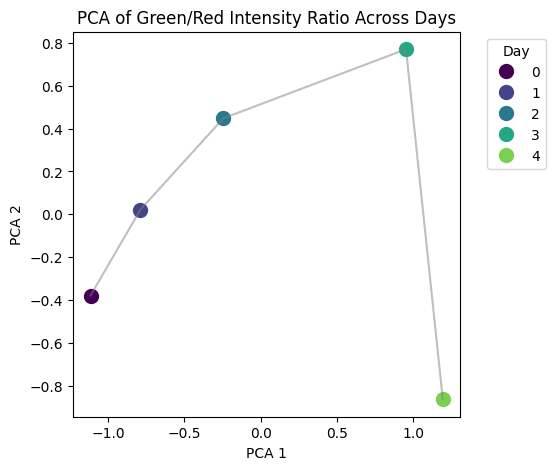

In [249]:
## run a quick PCA on this matrix to see if there are any clear patterns in the data
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(green_red_ratio_matrix.values.T)

plt.figure(figsize=(5, 5))
for i in range(pca_result.shape[0]):
    plt.plot(pca_result[i, 0], pca_result[i, 1], markersize=10, color=plt.cm.viridis(i / pca_result.shape[0]), marker='o', linestyle='', label=f'{green_red_ratio_matrix.columns[i]}')
plt.plot(pca_result[:, 0], pca_result[:, 1],color='grey',linestyle='-', alpha=0.5)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA of Green/Red Intensity Ratio Across Days')
# plt.colorbar()
plt.legend(title='Day', bbox_to_anchor=(1.05, 1), loc='upper left')


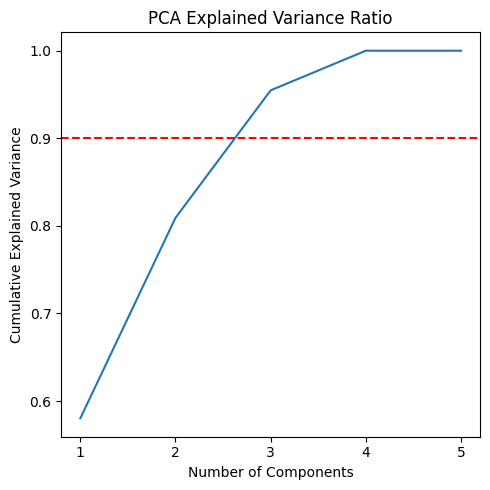

In [250]:
pca.explained_variance_ratio_
plt.figure(figsize=(5, 5))
plt.plot(np.arange(len(pca.explained_variance_ratio_))+1,np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.9, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(np.arange(len(pca.explained_variance_ratio_))+1)
plt.title('PCA Explained Variance Ratio')
plt.tight_layout()
# pca_result

In [251]:
green_red_ratio_matrix.dropna(inplace=True)

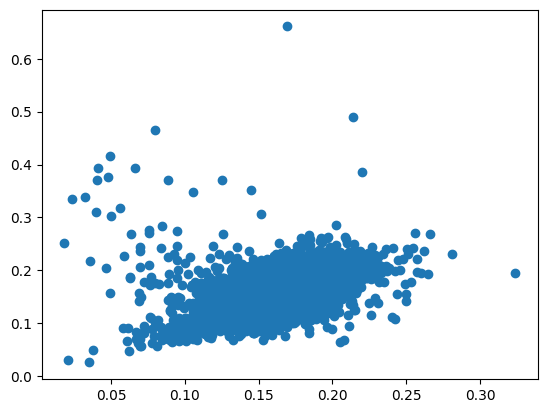

In [252]:
plt.plot(green_red_ratio_matrix[0], green_red_ratio_matrix[4], 'o')

In [253]:
## ROI residual plotting
roi_residual_path = r"D:\_data\_newAAV_2026\Fucci-Tri_avg_images\1050_data\analysis\roi_log_ratio_outputs_dark_median_corrected_meanMergeCPSAM_ROIs\shape_qc_filter\daywise_green_red_fit_residuals_20260526_150127\roi_metrics_with_green_red_fit_residuals.csv"
roi_residual_df = pd.read_csv(roi_residual_path)
roi_residual_df.head()

,roi_id,day,green,red,brightness,green_fraction,log2_green_over_red,day0_log2_green_over_red,delta_log2_green_over_red,green_day0,...,green_fit_signed_distance,day0_green_fit_residual,delta_green_fit_residual,day0_green_fit_signed_distance,delta_green_fit_signed_distance,min_green_fit_residual,max_green_fit_residual,green_fit_residual_range,last_green_fit_residual,green_fit_residual_sign_change_count
0,1,0,107.379836,1064.295428,1171.675264,0.091646,-3.297085,-3.297085,0.000000,107.379836,...,-66.723281,-67.548957,0.000000,-66.723281,0.000000,-67.548957,-46.720404,20.828553,-57.494201,0
1,1,1,95.949590,973.411489,1069.361079,0.089726,-3.329224,-3.297085,-0.032139,107.379836,...,-61.441204,-67.548957,5.370106,-66.723281,5.282077,-67.548957,-46.720404,20.828553,-57.494201,0
2,1,2,100.518171,979.194607,1079.712778,0.093097,-3.271330,-3.297085,0.025755,107.379836,...,-54.785138,-67.548957,12.137146,-66.723281,11.938144,-67.548957,-46.720404,20.828553,-57.494201,0
3,1,3,91.513482,840.206331,931.719812,0.098220,-3.184724,-3.297085,0.112361,107.379836,...,-46.187695,-67.548957,20.828553,-66.723281,20.535586,-67.548957,-46.720404,20.828553,-57.494201,0
4,1,4,101.083236,916.048066,1017.131301,0.099381,-3.167251,-3.297085,0.129834,107.379836,...,-56.853156,-67.548957,10.054757,-66.723281,9.870125,-67.548957,-46.720404,20.828553,-57.494201,0


In [254]:
roi_residual_df.columns[['residual' in col for col in roi_residual_df.columns]]
# roi_residual_df[['roi_id','day','green_red_fit_residual']]

Index(['green_fit_residual', 'day0_green_fit_residual',
       'delta_green_fit_residual', 'min_green_fit_residual',
       'max_green_fit_residual', 'green_fit_residual_range',
       'last_green_fit_residual', 'green_fit_residual_sign_change_count'],
      dtype='object')

In [255]:
roi_residual_df['green_fit_residual'][0:5]

0   -67.548957
1   -62.178851
2   -55.411811
3   -46.720404
4   -57.494201
Name: green_fit_residual, dtype: float64

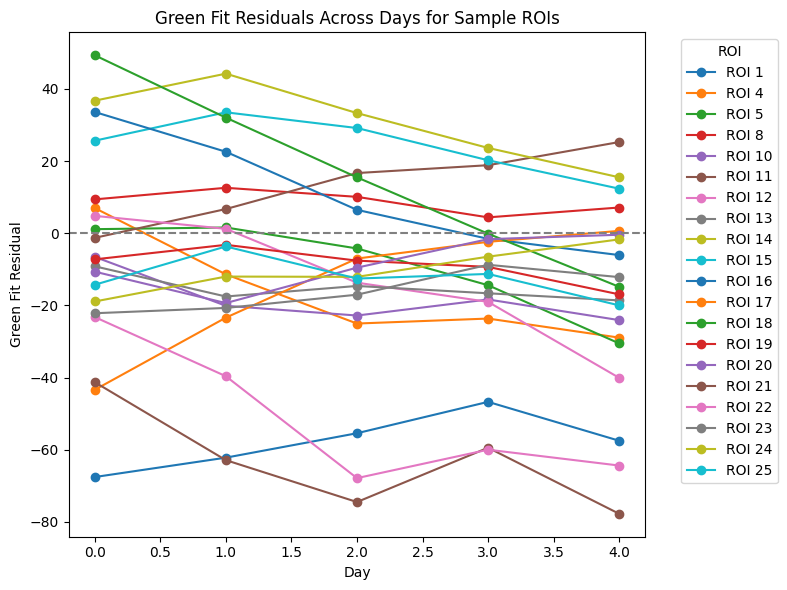

In [256]:
roi_residual_df_melted = roi_residual_df.melt(id_vars=['day', 'roi_id'], value_vars=['green_fit_residual'], var_name='metric', value_name='value')
roi_residual_df_melted.head()

plt.figure(figsize=(8, 6))

for roi_id in roi_residual_df_melted['roi_id'].unique()[0:20]:
    roi_data = roi_residual_df_melted[roi_residual_df_melted['roi_id'] == roi_id]
    plt.plot(roi_data['day'], roi_data['value'], marker='o', label=f'ROI {roi_id}')

plt.axhline(y=0, color='grey', linestyle='--')
plt.xlabel('Day')
plt.ylabel('Green Fit Residual')
plt.title('Green Fit Residuals Across Days for Sample ROIs')
plt.legend(title='ROI', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


Text(0.5, 1.0, 'Green Fit Residual Across Days')

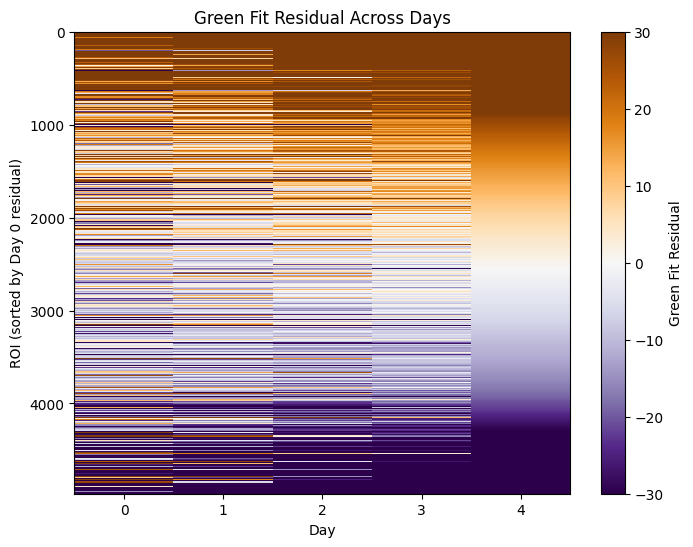

In [257]:
roi_residual_df_pivot = roi_residual_df_melted.pivot(index='roi_id', columns='day', values='value')
roi_residual_df_pivot.head()


## plot heatmap of green fit residuals across days for each ROI
plt.figure(figsize=(8, 6))
isort = np.argsort(-roi_residual_df_pivot[4])
roi_residual_df_pivot = roi_residual_df_pivot.iloc[isort, :]
plt.imshow(roi_residual_df_pivot, aspect='auto', cmap='PuOr_r',interpolation='none',vmin=-30, vmax=30)
plt.colorbar(label='Green Fit Residual')
plt.xlabel('Day')
plt.ylabel('ROI (sorted by Day 0 residual)')
plt.title('Green Fit Residual Across Days')


In [258]:
## plot the same heatmap but only plot the ROI have fit redisual that are both positive and negative in those 5 days
## check if this row values is signed?
## 

def same_sign_min_max(arr):
    if not arr:
        return True
    return min(arr) * max(arr) >= 0

## use this function to find those ROIs passing it
# crossing_roi_idx = 
cols = roi_residual_df_pivot.columns
roi_residual_df_pivot["passing"] = roi_residual_df_pivot[cols].apply(lambda row: same_sign_min_max(row.tolist()), axis=1)
roi_residual_df_pivot_crossing = roi_residual_df_pivot[roi_residual_df_pivot['passing']].drop(columns='passing')
roi_residual_df_pivot_crossing.shape


(3409, 5)

Text(0.5, 1.0, 'Green Fit Residual Across Days')

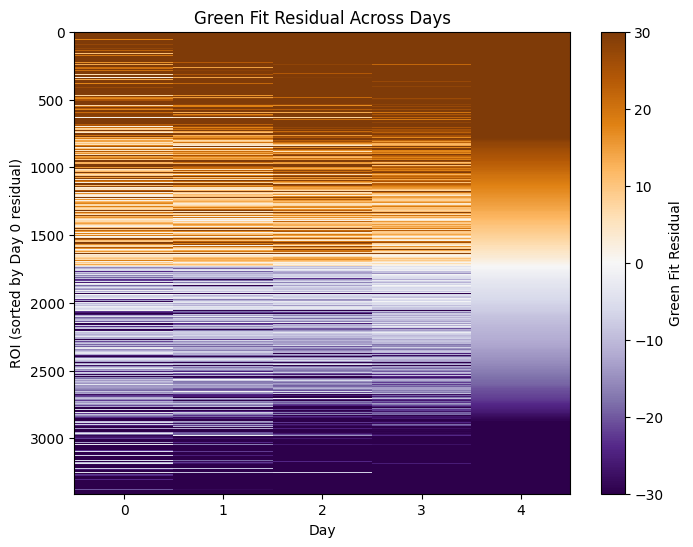

In [259]:
## plot heatmap of green fit residuals across days for each ROI
plt.figure(figsize=(8, 6))
isort = np.argsort(-roi_residual_df_pivot_crossing[0])
roi_residual_df_pivot = roi_residual_df_pivot_crossing.iloc[isort, :]
plt.imshow(roi_residual_df_pivot_crossing, aspect='auto', cmap='PuOr_r',interpolation='none',vmin=-30, vmax=30)
plt.colorbar(label='Green Fit Residual')
plt.xlabel('Day')
plt.ylabel('ROI (sorted by Day 0 residual)')
plt.title('Green Fit Residual Across Days')


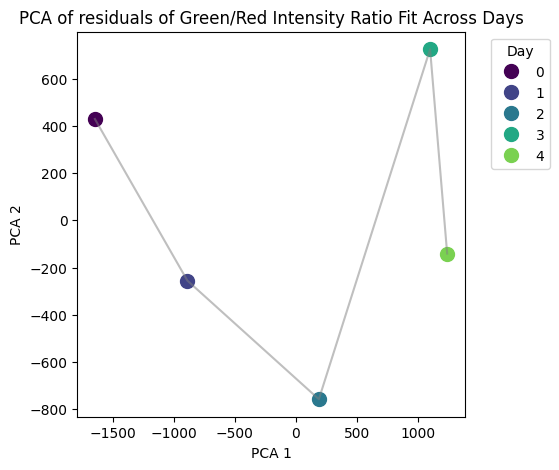

In [193]:
## run a quick PCA on this matrix to see if there are any clear patterns in the data
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(roi_residual_df_pivot.values.T)

plt.figure(figsize=(5, 5))
for i in range(pca_result.shape[0]):
    plt.plot(pca_result[i, 0], pca_result[i, 1], markersize=10, color=plt.cm.viridis(i / pca_result.shape[0]), marker='o', linestyle='', label=f'{green_red_ratio_matrix.columns[i]}')
plt.plot(pca_result[:, 0], pca_result[:, 1],color='grey',linestyle='-', alpha=0.5)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA of residuals of Green/Red Intensity Ratio Fit Across Days')
# plt.colorbar()
plt.legend(title='Day', bbox_to_anchor=(1.05, 1), loc='upper left')


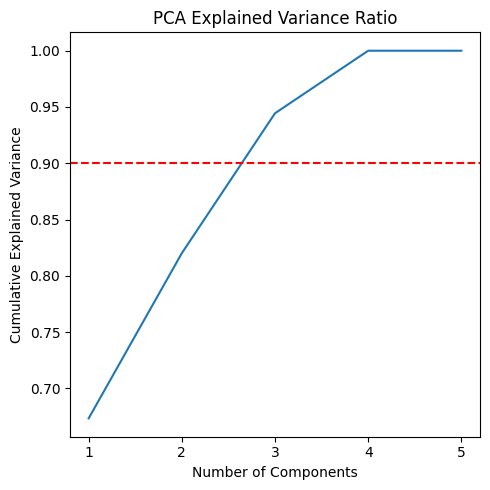

In [192]:
pca.explained_variance_ratio_
plt.figure(figsize=(5, 5))
plt.plot(np.arange(len(pca.explained_variance_ratio_))+1,np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.9, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(np.arange(len(pca.explained_variance_ratio_))+1)
plt.title('PCA Explained Variance Ratio')
plt.tight_layout()
# pca_result